# EM casing response dipole source

In [1]:
import numpy as np
import os
import scipy.sparse as sp
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap, Normalize, SymLogNorm
from matplotlib import cm as colormap
import time
from string import ascii_lowercase
import pickle
from multiprocessing import Pool

# SimPEG, discretize/
import discretize
from discretize import utils
from simpeg.electromagnetics import frequency_domain as fdem
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.electromagnetics.utils import line_through_faces
from simpeg import(
    maps, Report, data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils
)
from pymatsolver import Pardiso

from utils import pad_for_casing_and_data

In [2]:
dpi_high=300
dpi_low=100

In [3]:
from matplotlib import rcParams
rcParams["font.size"] = 16

In [4]:
directory_path = "/t40array/lheagy/casing-upscaling"

In [5]:
def ensure_directory_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Directory '{directory_path}' created.")
    else:
        print(f"Directory '{directory_path}' already exists.")

# Example usage
ensure_directory_exists(directory_path)

Directory '/t40array/lheagy/casing-upscaling' already exists.


In [6]:
save_figures = False
fig_dir_high = "figures"
fig_dir_low = "low-rez-figures"

dpi_high=400
dpi_low=150

## Simulation parameters

In [7]:
# # conductivities
sigma_air = 1e-1
sigma_back = np.r_[1e-1]
casing_l = 1
sigma_casing = 5e6
mur_casing = np.r_[1, 2, 10, 25, 50, 100, 150, 200]

# # casing geometry
casing_b = 5e-2  
casing_t = 1e-2 #np.r_[5e-3, 7.5e-3, 10e-3, 12.5e-3, 15e-3, 20e-3]
casing_a = casing_b - casing_t

In [8]:
src_dz = -10
src_z = 0 #np.r_[-100, -250, -400, -495, -500, -550, -600]

In [215]:
# generate a mesh
hx = pad_for_casing_and_data(
   casing_outer_radius = casing_b,
    csx1 = casing_t/8, 
    csx2 = 25, 
    pfx1 = 1.3,
    pfx2 = 1.3, 
    domain_x = 600, 
    npadx = 18
)

pfz = 1.3
npad_z = 38
csz = 0.1
n_core_extra = 10
ncore_z = int(np.max([src_dz, casing_l]) / csz) 
hz = discretize.utils.unpack_widths(
    [(csz, npad_z, -pfz), (csz, ncore_z), (csz, npad_z, pfz)]
)

<AxesSubplot:xlabel='x', ylabel='z'>

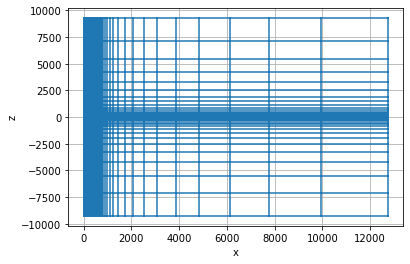

In [216]:
mesh = discretize.CylindricalMesh(
    [hx, np.r_[2*np.pi], hz], origin=np.r_[0, 0, -np.sum(hz)/2],
)

fig, ax = plt.subplots(1, 1)
mesh.plot_grid(ax=ax)
# ax.set_xlim([0, 5])
# ax.set_ylim(-50, 10)

In [217]:
mesh.n_cells

10406

In [218]:
def get_physical_property_model(mesh, casing_a, casing_b, casing_l, sigma_back, sigma_casing, sigma_air=sigma_air, mur_casing=1):

    model = np.ones(mesh.n_cells)*sigma_air
    model[mesh.cell_centers[:, 2] < 0] = sigma_back

    mur = np.ones(mesh.n_cells)

    inds_casing_x = (
        (mesh.cell_centers[:, 0] > casing_a) & 
        (mesh.cell_centers[:, 0] < casing_b)
    )
    inds_casing_z = (
        (mesh.cell_centers[:, 2] < casing_l/2) &
        (mesh.cell_centers[:, 2] > -casing_l/2)
    )
    inds_casing = inds_casing_x & inds_casing_z

    model[inds_casing] = sigma_casing
    mur[inds_casing] = mur_casing

    return model, mur

    

In [219]:
sigma_back

array([0.1])

In [220]:
models = {}
for mur in mur_casing:
    key = f"casing_sig{sigma_casing:1.0e}_mur{mur:1.0f}"
    sig_model, mur_model = get_physical_property_model(mesh, casing_a, casing_b, casing_l, sigma_back[0], sigma_casing, mur_casing=mur)
    models[key] = {
        "sigma": sig_model, 
        "mur": mur_model
    }
keys = list(models.keys())

In [221]:
keys

['casing_sig5e+06_mur1',
 'casing_sig5e+06_mur2',
 'casing_sig5e+06_mur10',
 'casing_sig5e+06_mur25',
 'casing_sig5e+06_mur50',
 'casing_sig5e+06_mur100',
 'casing_sig5e+06_mur150',
 'casing_sig5e+06_mur200']

In [222]:
casing_t

0.01

In [223]:
models_solid = {}

sigma_solid = sigma_casing * (casing_b**2 - casing_a**2) / casing_b**2
mur_solid = mur_casing * (casing_t / (2*casing_b)) * (3 - casing_t / casing_b)

for i, mur in enumerate(mur_solid): 
    sig_model, mur_model = get_physical_property_model(mesh, 0, casing_b, casing_l, sigma_back[0], sigma_solid, mur_casing=mur)
    models_solid[keys[i]] = {
        "sigma": sig_model,
        "mur": mur_model
    }

In [224]:
def plot_casing(model, xlim=None, zlim=None, vmin=None, vmax=None, ax=None, cb_label=None, logscale=True, show_cb=False): 
    if ax is None: 
        fig, ax = plt.subplots(1, 1)
    if logscale is True: 
        pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax), "cmap":"Spectral_r"}
    else: 
        pcolor_opts={"norm":Normalize(vmin=vmin, vmax=vmax), "cmap":"Spectral_r"}
    out = mesh.plot_image(
        model, pcolor_opts=pcolor_opts, ax=ax, mirror=True
    )

    if show_cb is True: 
        cb = plt.colorbar(out[-1], shrink=0.5)
        cb.set_label(cb_label)

    if xlim is not None: 
        ax.set_xlim(xlim)
    if zlim is not None: 
        ax.set_ylim(zlim)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    return ax, out

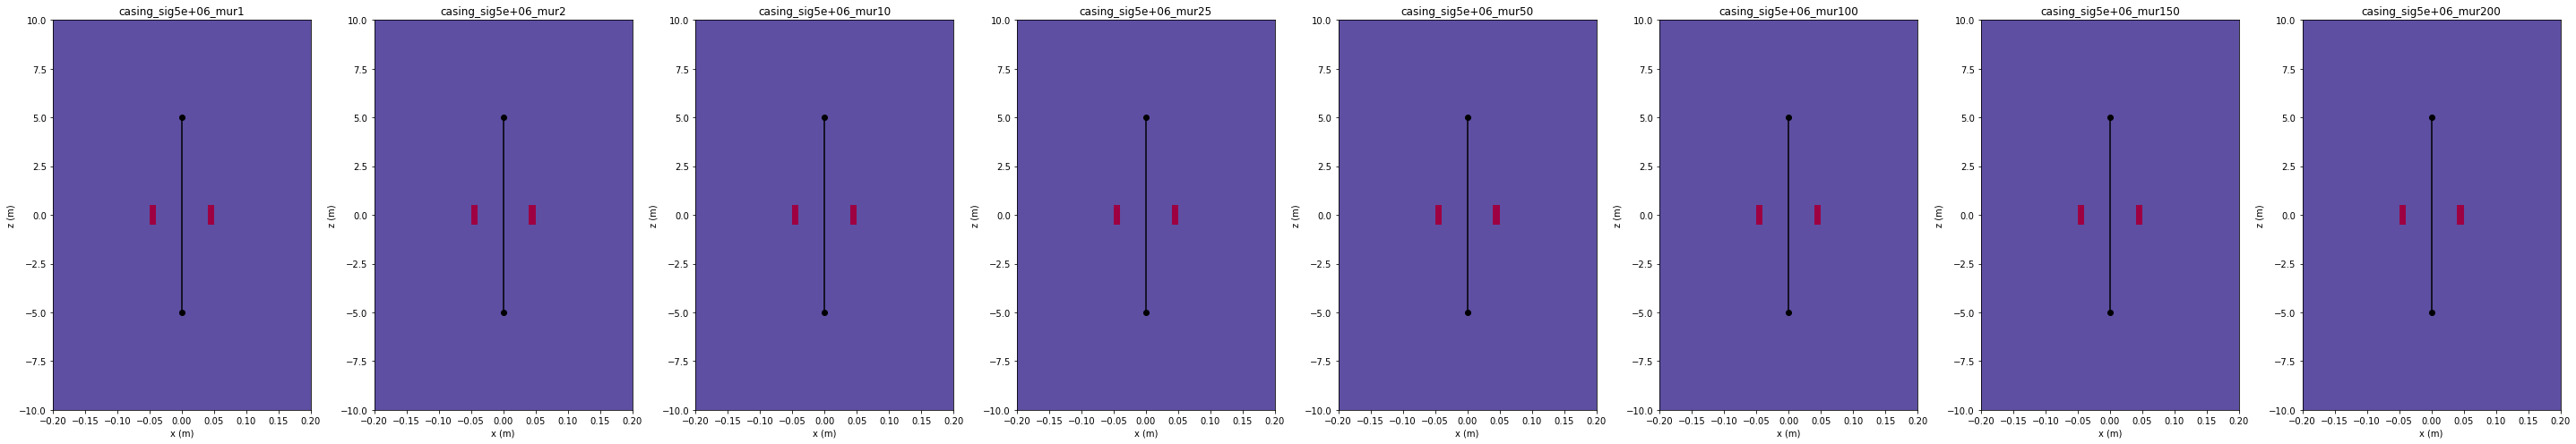

In [225]:
plot_keys = keys
fig, ax = plt.subplots(1, len(plot_keys), figsize=(5*len(plot_keys), 7))

xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-10, 10]
vmin = sigma_air
vmax = sigma_casing

for i, key in enumerate(plot_keys):
    plot_casing(models[key]["sigma"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[i])
    ax[i].set_title(key)
    ax[i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

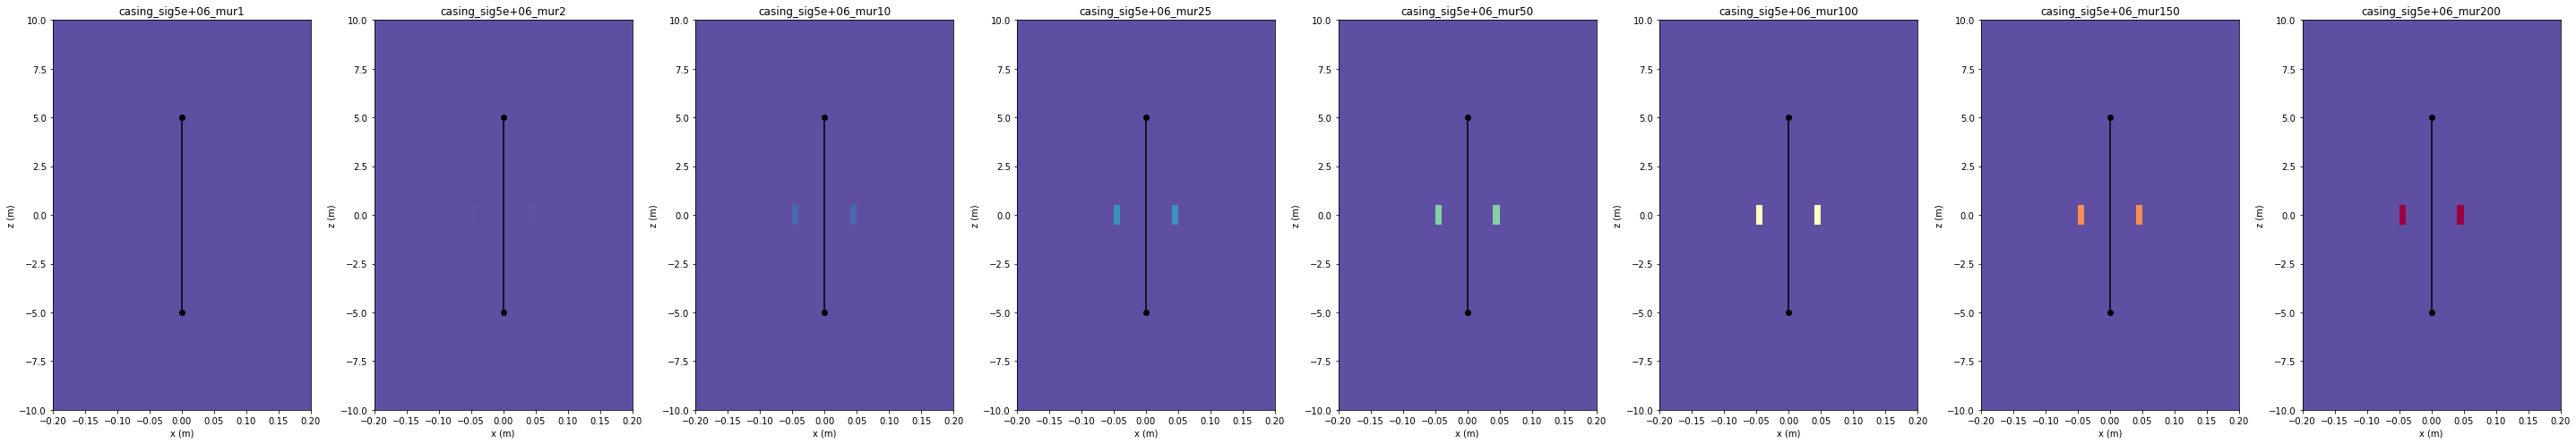

In [226]:
plot_keys = keys
fig, ax = plt.subplots(1, len(plot_keys), figsize=(5*len(plot_keys), 7))

xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-10, 10]
vmin = 1
vmax = mur_casing.max()

for i, key in enumerate(plot_keys):
    plot_casing(models[key]["mur"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[i], logscale=False)
    ax[i].set_title(key)
    ax[i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

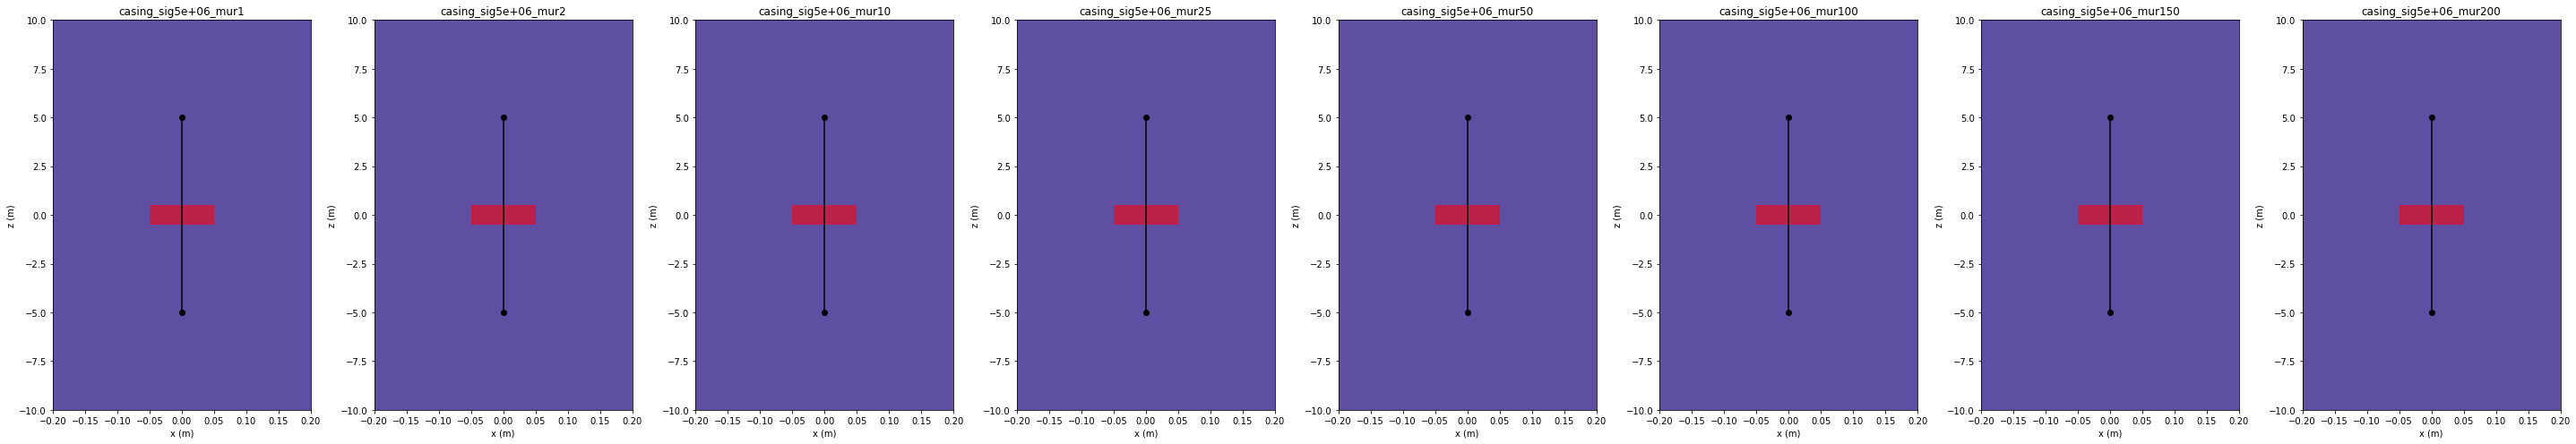

In [227]:
plot_keys = keys
fig, ax = plt.subplots(1, len(plot_keys), figsize=(5*len(plot_keys), 7))

xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-10, 10]
vmin = sigma_air
vmax = sigma_casing

for i, key in enumerate(plot_keys):
    plot_casing(models_solid[key]["sigma"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[i])
    ax[i].set_title(key)
    ax[i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

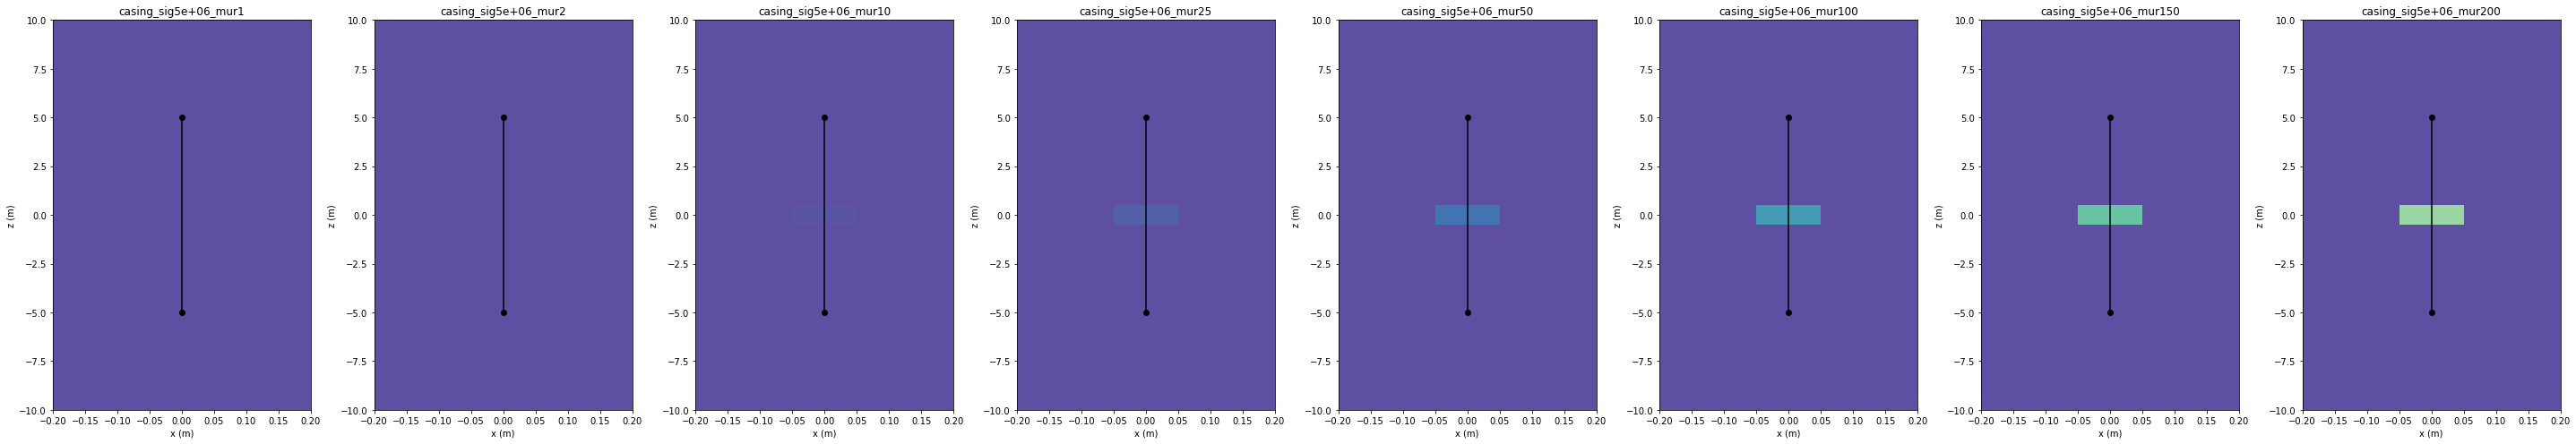

In [228]:
plot_keys = keys
fig, ax = plt.subplots(1, len(plot_keys), figsize=(5*len(plot_keys), 7))

xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-10, 10]
vmin = 1
vmax = mur_casing.max()

for i, key in enumerate(plot_keys):
    plot_casing(models_solid[key]["mur"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[i], logscale=False)
    ax[i].set_title(key)
    ax[i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

## set up the simulations

In [229]:
frequencies = np.r_[1e-1] #10**np.linspace(-1, 4, 36)
frequencies

array([0.1])

In [230]:
src_list = []
src_locations = np.array([
    [0, 0, src_z+src_dz/2.],
    [0, 0, src_z-src_dz/2.]
])
for f in frequencies: 
    src = fdem.sources.LineCurrent([], location=src_locations, frequency=f)
    src_list.append(src)

wires = maps.Wires(("sigma", mesh.n_cells), ("mur", mesh.n_cells))
permeability_map = maps.MuRelative(mesh)

survey = fdem.Survey(src_list)

sim = fdem.simulation.Simulation3DMagneticField(
    mesh=mesh, sigmaMap=wires.sigma, muMap=permeability_map * wires.mur,
    survey=survey, solver=Pardiso, #mu=mur * mu_0
#     verbose=True
)

In [231]:
def run_simulation(key, model_dict):
    
    filename = os.path.sep.join([directory_path, key])

    t = time.time()
    print(f"starting {key}..., saving to {filename}")
    fields = sim.fields(np.r_[model_dict[key]["sigma"], model_dict[key]["mur"]])
    print(f" ... done. {time.time()-t:1.2e} \n")
    
    np.save(filename, fields[:, "hSolution"])

    return fields

In [232]:
background_model = {
    "background" : {
    "sigma": np.ones(mesh.n_cells) * sigma_back, 
    "mur": np.ones(mesh.n_cells)
}}
background = run_simulation("background", background_model)

starting background..., saving to /t40array/lheagy/casing-upscaling/background
 ... done. 9.18e-02 



In [233]:
fields = {}
for key in keys: 
    if key not in fields: 
        fields[key] = run_simulation(key, models)

starting casing_sig5e+06_mur1..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur1
 ... done. 7.51e-02 

starting casing_sig5e+06_mur2..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur2
 ... done. 6.81e-02 

starting casing_sig5e+06_mur10..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur10
 ... done. 6.97e-02 

starting casing_sig5e+06_mur25..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur25
 ... done. 6.96e-02 

starting casing_sig5e+06_mur50..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur50
 ... done. 6.80e-02 

starting casing_sig5e+06_mur100..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur100
 ... done. 6.85e-02 

starting casing_sig5e+06_mur150..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur150
 ... done. 6.84e-02 

starting casing_sig5e+06_mur200..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur200
 ... done. 6.77e-02 



In [234]:
fields_solid = {}

for key in keys: 
    if key not in fields_solid: 
        fields_solid[key] = run_simulation(key, models_solid)

starting casing_sig5e+06_mur1..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur1
 ... done. 7.03e-02 

starting casing_sig5e+06_mur2..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur2
 ... done. 4.62e-02 

starting casing_sig5e+06_mur10..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur10
 ... done. 4.63e-02 

starting casing_sig5e+06_mur25..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur25
 ... done. 4.55e-02 

starting casing_sig5e+06_mur50..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur50
 ... done. 4.54e-02 

starting casing_sig5e+06_mur100..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur100
 ... done. 4.61e-02 

starting casing_sig5e+06_mur150..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur150
 ... done. 4.49e-02 

starting casing_sig5e+06_mur200..., saving to /t40array/lheagy/casing-upscaling/casing_sig5e+06_mur200
 ... done. 4.56e-02 



In [235]:
# def load_fields(name, conductivity, mur):
#     solution = np.load(f"{directory}/fields_{name}.npy")
#     sim = generate_simulation(mur)
#     sim.model = conductivity
#     f = sim.fieldsPair(sim)
#     f[:, sim._solutionType] = solution
#     return f

In [236]:
def plot_fields_cross_section(
    field_plot, xlim=500*np.r_[-1, 1], zlim=np.r_[-1000, 10], component="real", ax=None, vmin=None, vmax=None, aspect=True,
    plot_source=False
):
    if ax is None: 
        fig, ax = plt.subplots(1,1)

    if len(field_plot) == mesh.n_faces: 
        field_plot = mesh.average_face_to_cell_vector * np.squeeze(field_plot)
        
        out = mesh.plot_image(
            getattr(field_plot, component), "CCv", view="vec", 
            range_x = xlim, range_y = zlim,
            sample_grid = np.r_[np.diff(xlim)/100, np.diff(zlim)/100],
            mirror=True, #mirror_data=field_mirror,
            ax=ax, 
            pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax)},
            stream_threshold=vmin
        )

    elif len(field_plot) == mesh.n_edges: 
        field_plot = mesh.average_edge_to_cell_vector * np.squeeze(field_plot)
        
        out = mesh.plot_image(
            getattr(field_plot, component), "CC",  
            range_x = xlim, range_y = zlim,
            mirror=True, mirror_data=-1*field_plot,
            ax=ax, 
            pcolor_opts={
                "norm":SymLogNorm(linthresh=vmin if vmin is not None else 1e-12, vmin=-1*vmax if vmax is not None else None, vmax=vmax),
                "cmap":"RdBu_r",
            },
            stream_threshold=vmin
        )

    if plot_source is True: 
        ax.plot(src_locations[:, 0], src_locations[:, 2], "w", lw=2)
    
    cb = plt.colorbar(out[0], ax=ax)
    # cb.set_label("Electric Field (V/m)")
    if aspect is True:
        ax.set_aspect(1)

    return out, cb

In [237]:
# dc response 

dc_src_list = [
    dc.sources.Dipole([], location_a=src_locations[0,:], location_b=src_locations[-1,:])
]
dc_survey = dc.Survey(dc_src_list)
dc_sim = dc.simulation.Simulation3DCellCentered(
    mesh=mesh, sigmaMap=maps.IdentityMap(mesh),
    survey=dc_survey, solver=Pardiso, bc_type="Dirichlet",
#     verbose=True
)

In [238]:
dc_fields_hollow = dc_sim.fields(models[keys[0]]["sigma"])
dc_fields_solid = dc_sim.fields(models_solid[keys[0]]["sigma"])

dc_fields_background = dc_sim.fields(background_model["background"]["sigma"])

In [239]:
def getAmmr(mur):
    vol = mesh.cell_volumes
    Div = discretize.utils.sdiag(vol) * mesh.face_divergence
    MeMuI = mesh.get_edge_inner_product(mur * mu_0, invert_matrix=True)
    mui = 1./(mur*mu_0)
    return (
        mesh.edge_curl
        * MeMuI
        * mesh.edge_curl.T.tocsr()
        - Div.T.tocsr()
        * discretize.utils.sdiag(1.0 / vol * mui)
        * Div  # stabalizing term. See (Chen, Haber & Oldenburg 2002)
    )

In [240]:
dc_src = dc_src_list[0]

In [241]:
js_dc = line_through_faces(
    mesh, dc_src.location, normalize_by_area=True
)

In [242]:
def solve_mmr(mur, dc_fields):
    Ammr = getAmmr(mur)
    Ammr_inv = Pardiso(Ammr)
    rhs = js_dc + dc_fields[:, "j"].flatten()
    mmr_a = Ammr_inv * rhs
    
    MeMuI = mesh.get_edge_inner_product(mur * mu_0, invert_matrix=True)
    b_mmr = mesh.edge_curl.T * mmr_a
    h_mmr = MeMuI * b_mmr

    return {
        "a": mmr_a, 
        "b": mesh.get_edge_inner_product(invert_matrix=True) * b_mmr, 
        "h": h_mmr
    }


    

In [243]:
mmr_hollow = {}
mmr_solid = {}

for key in keys:
    mmr_hollow[key] = solve_mmr(models[key]["mur"], dc_fields_hollow)
    mmr_solid[key] = solve_mmr(models_solid[key]["mur"], dc_fields_solid)

mmr_background = solve_mmr(background_model["background"]["mur"], dc_fields_background)

In [244]:
plot_inds = mesh.edges[:, 0] == mesh.nodes_x[np.argmin(np.abs(mesh.nodes_x - casing_b)) - 1]

In [245]:
# fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# xlim = np.r_[0, -casing_l]

# solution = mmr_hollow

# ax[0].plot(mesh.nodes_z, solution[keys[0]]["b"][plot_inds], color="k")

# for i, key in enumerate(keys[1:]):
#     ax[0].plot(mesh.nodes_z, solution[key]["b"][plot_inds], label=f"{key.split('_')[2][3:]} $\mu_0$", color=f"C{i}")
#     # ax[0].plot(mesh.nodes_z, mur_casing[i+1]*b_mmr[keys[0]][plot_inds], label=f"{key.split('_')[2][3:]} $\mu_0$", color=f"C{i}", ls="--")
#     ax[1].plot(mesh.nodes_z, ((solution[key]["b"]-solution[keys[0]]["b"])/solution[keys[0]]["b"])[plot_inds], label=key)

# ax[0].legend()
# for a in ax:
#     a.set_xlim(xlim)
#     a.grid()
# # ax[0].set_ylim(-1e-8, 3e-8)
# plt.tight_layout()

In [246]:
for i, key in enumerate(keys[1:]):  
    hollow_sol = ((mmr_hollow[key]["b"]-mmr_hollow[keys[0]]["b"])/mmr_hollow[keys[0]]["b"])[plot_inds]
    # solid_sol = ((mmr_solid[key]["b"]-mmr_solid[keys[0]]["b"])/mmr_solid[keys[0]]["b"])[plot_inds]
    # print(f"{key:25s}: {hollow_sol.max():6.2f}, {solid_sol.max():6.2f}, {hollow_sol.max()/solid_sol.max():6.2f}")

In [247]:
for i, key in enumerate(keys[1:]):  
    hollow_sol = (mmr_hollow[key]["b"])[plot_inds]
    # solid_sol = (mmr_solid[key]["b"])[plot_inds]
    # print(f"{key:25s}: {hollow_sol.max():1.2e}, {solid_sol.max():1.2e}, {hollow_sol.max()/solid_sol.max():6.2f}")

In [248]:
def plot_field_at_depth(field, zloc=0, xlim=np.r_[0, 0.2], ylim=None, ax=None, label=None, color=None, ls=None, plottype="plot", discontinuous=None):
    freq_ind=0
    field = np.squeeze(field)
    
    if ax is None: 
        fig, ax = plt.subplots(1, 1)
    
    if len(field) == mesh.n_edges: 
        plot_inds = mesh.edges[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - zloc))]
        x = mesh.nodes_x
        
#     elif len(field) == mesh.n_faces_x: 
#         print("faces_x")
#         plot_inds_ex = mesh.faces_x[:, 2] == mesh.cell_centers_z[np.argmin(np.abs(mesh.cell_centers_z - zloc))]
#         plot_inds = np.hstack([plot_inds_ex, np.zeros(mesh.n_faces_z, dtype=bool)]) 
#         x = mesh.nodes_x
        
    elif len(field) == mesh.n_faces_z:
        plot_inds_ez = mesh.faces_z[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - zloc))]
        plot_inds = np.hstack([np.zeros(mesh.n_faces_x, dtype=bool), plot_inds_ez])
        x = mesh.cell_centers_x
    
    elif len(field) == mesh.n_cells: 
        plot_inds = mesh.cell_centers[:, 2] == mesh.cell_centers_z[np.argmin(np.abs(mesh.cell_centers_z - zloc))]
        x = mesh.cell_centers_x

    csx = mesh.h[0].min()
    inds_inside = x < casing_a
    inds_casing = (x <= casing_b + csx/2) & (x >= casing_a)
    inds_outside = x > casing_b + csx/2

    if discontinuous == "hollow":
        inds = [inds_inside, inds_casing, inds_outside]
    elif discontinuous == "solid": 
        inds = [inds_inside | inds_casing, inds_outside]
    else: 
        inds = [inds_inside | inds_casing | inds_outside]

    for j, ind in enumerate(inds): 
        getattr(ax, plottype)(x[ind], field[plot_inds][ind], ls=ls, color=color, label=label if j == 0 else None) 
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    # ax.grid()
        
    return ax

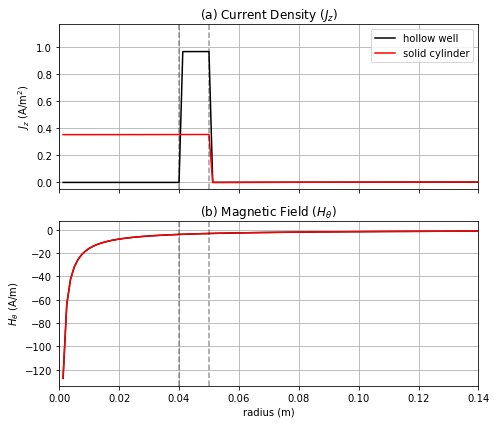

In [249]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6))

xlim = np.r_[0, 0.14]
zloc = 0

plot_field_at_depth(dc_fields_hollow[:, "j"][mesh.n_faces_x:], zloc=zloc, color="k", ax=ax[0], xlim=xlim, label="hollow well")
plot_field_at_depth(mmr_hollow[keys[0]]["h"], zloc=zloc, color="k", ax=ax[1], xlim=xlim, label="hollow well")

plot_field_at_depth(dc_fields_solid[:, "j"][mesh.n_faces_x:], zloc=zloc, color="r", ax=ax[0], xlim=xlim, label="solid cylinder")
plot_field_at_depth(mmr_solid[keys[0]]["h"], zloc=zloc, color="r", ax=ax[1], xlim=xlim, label="solid cylinder")

for a in ax.flatten():
    a.grid()
    ylim = a.get_ylim()
    a.set_ylim(ylim[0], ylim[1]*1.15)
    a.vlines([casing_a, casing_b], ymin=ylim[0], ymax=ylim[1]*1.2, ls="--", color="k", alpha=0.4)

ax[0].legend()
ax[0].set_title("(a) Current Density ($J_z$)")
ax[1].set_title("(b) Magnetic Field ($H_{\\theta}$)")
ax[1].set_xlabel("radius (m)")

ax[0].set_ylabel("$J_z$ (A/m$^2$)")
ax[1].set_ylabel("$H_{\\theta}$ (A/m)")

plt.tight_layout()

# fig.savefig("figures/dc_response", dpi=dpi_high)
# fig.savefig("low-rez-figures/dc_response", dpi=dpi_low) 

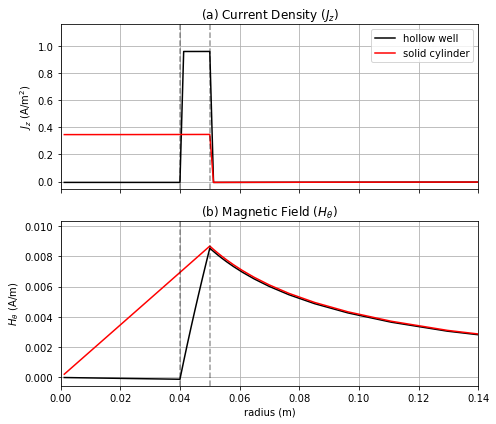

In [250]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6))

xlim = np.r_[0, 0.14]
zloc = 0

plot_field_at_depth(dc_fields_hollow[:, "j"][mesh.n_faces_x:] - dc_fields_background[:, "j"][mesh.n_faces_x:], zloc=zloc, color="k", ax=ax[0], xlim=xlim, label="hollow well")
plot_field_at_depth(mmr_hollow[keys[0]]["h"] - mmr_background["h"], zloc=zloc, color="k", ax=ax[1], xlim=xlim, label="hollow well")

plot_field_at_depth(dc_fields_solid[:, "j"][mesh.n_faces_x:] - dc_fields_background[:, "j"][mesh.n_faces_x:], zloc=zloc, color="r", ax=ax[0], xlim=xlim, label="solid cylinder")
plot_field_at_depth(mmr_solid[keys[0]]["h"] - mmr_background["h"], zloc=zloc, color="r", ax=ax[1], xlim=xlim, label="solid cylinder")

for a in ax.flatten():
    a.grid()
    ylim = a.get_ylim()
    a.set_ylim(ylim[0], ylim[1]*1.15)
    a.vlines([casing_a, casing_b], ymin=ylim[0], ymax=ylim[1]*1.2, ls="--", color="k", alpha=0.4)

ax[0].legend()
ax[0].set_title("(a) Current Density ($J_z$)")
ax[1].set_title("(b) Magnetic Field ($H_{\\theta}$)")
ax[1].set_xlabel("radius (m)")

ax[0].set_ylabel("$J_z$ (A/m$^2$)")
ax[1].set_ylabel("$H_{\\theta}$ (A/m)")

plt.tight_layout()

# fig.savefig("figures/dc_response", dpi=dpi_high)
# fig.savefig("low-rez-figures/dc_response", dpi=dpi_low) 

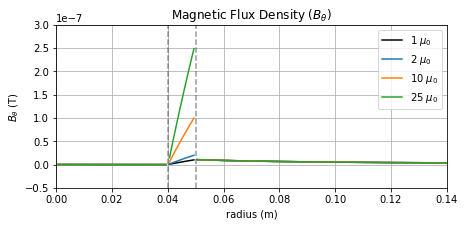

In [251]:
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(7, 3))


for i, k in enumerate([keys[i] for i in [0, 1, 2, 3]]): 
    if i == 0: 
        color = "k"
    else:
        color = f"C{i-1}"
    
    hcc = mu_0 * mesh.average_edge_to_cell * (mmr_hollow[k]["h"] - mmr_background["h"])
    plot_field_at_depth(
        models[k]["mur"] * hcc, zloc=zloc, color=color, ax=ax, xlim=xlim, label=f"{k.split('_')[-1][3:]} $\mu_0$", 
        discontinuous="hollow",
        # plottype=lot
    )

ax.set_ylim(np.r_[-0.05, 0.3]*1e-6)
ax.legend()
ax.grid()

ylim = ax.get_ylim()
ax.vlines([casing_a, casing_b], ymin=ylim[0], ymax=ylim[1]*1.2, ls="--", color="k", alpha=0.4)

ax.legend()
ax.set_title("Magnetic Flux Density ($B_{\\theta}$)")
ax.set_ylabel("$B_{\\theta}$ (T)")
ax.set_xlabel("radius (m)")

fig.savefig("figures/dc_response_B", dpi=dpi_high)
fig.savefig("low-rez-figures/dc_response_B", dpi=dpi_low) 

In [252]:
# remove the casing and simulate it as a magnetic source

In [275]:
def solve_inductive_part(b_dc):
    
    # b_src = np.zeros(mesh.n_edges)
    # inds_casing = (mesh.edges[:, 0] < casing_b) & (mesh.edges[:, 2] < casing_l/2) & (mesh.edges[:, 2] > -casing_l/2)
    # b_src[inds_casing] = b_dc[inds_casing]
    b_src = b_dc
    
    src_list_magnetic = []
    
    for f in frequencies: 
        src_magnetic = fdem.sources.RawVec_m([], s_m=-1j*2*np.pi*f*b_src, location=None, frequency=f, integrate=True)
        src_list_magnetic.append(src_magnetic)

    wires = maps.Wires(("sigma", mesh.n_cells), ("mur", mesh.n_cells))

    survey_magnetic = fdem.Survey(src_list_magnetic)

    sim_magnetic = fdem.simulation.Simulation3DMagneticField(
        mesh=mesh, sigmaMap=wires.sigma, muMap=maps.MuRelative(mesh) * wires.mur,
        survey=survey_magnetic, solver=Pardiso, #mu=mur * mu_0
    #     verbose=True
    )
    
    return sim_magnetic.fields(np.hstack([v for v in background_model["background"].values()]))
    # return sim_magnetic.fields(np.hstack([v for v in models[keys[0]].values()]))

In [276]:
inductive_fields = {}

for key, val in mmr_hollow.items(): 
    inductive_fields[key] = solve_inductive_part(val["b"])

# look at secondary fields due to magnetic permeability 


In [277]:
fields.keys()

dict_keys(['casing_sig5e+06_mur1', 'casing_sig5e+06_mur2', 'casing_sig5e+06_mur10', 'casing_sig5e+06_mur25', 'casing_sig5e+06_mur50', 'casing_sig5e+06_mur100', 'casing_sig5e+06_mur150', 'casing_sig5e+06_mur200'])

In [278]:
keys

['casing_sig5e+06_mur1',
 'casing_sig5e+06_mur2',
 'casing_sig5e+06_mur10',
 'casing_sig5e+06_mur25',
 'casing_sig5e+06_mur50',
 'casing_sig5e+06_mur100',
 'casing_sig5e+06_mur150',
 'casing_sig5e+06_mur200']

In [279]:
def plot_magnetic(
    field_plot, ax=None, xlim = 20*np.r_[-1, 1], zlim=np.r_[-20, 20],
    colorbar=False, ylabels=True, vmax=None
):
    """
    A function for plotting the current density on a cyl mesh. This assumes the "fields" 
    are defined earlier as a dictionary and you are interested in plotting the current 
    density due to the model corresponding with the provided "key" at time ti. 
    """
    field_plot = np.squeeze(field_plot)
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    if len(field_plot) == mesh.n_edges_y: 
        field_plot = mesh.average_edge_y_to_cell * np.squeeze(field_plot)
    
    if vmax is not None: 
        pcolor_opts={"norm":Normalize(vmin=-vmax, vmax=vmax), "cmap":"coolwarm"}
    else: 
        pcolor_opts = {"cmap":"coolwarm"}
    out = mesh.plot_image(
        field_plot, ax=ax, 
        mirror=True, mirror_data = -field_plot,
        pcolor_opts=pcolor_opts
    )
    
    ax.set_xlim(xlim)
    ax.set_ylim(zlim)
    
    if colorbar is True: 
        cb = plt.colorbar(out[0], ax=ax, orientation="horizontal")
    
    if ylabels is False: 
        ax.set_ylabel("")
        ax.set_yticklabels("")

    return ax

In [280]:
def plot_electric(
    field_plot, ax=None, xlim=20*np.r_[-1, 1], zlim=np.r_[-20, 20],
    colorbar=False, ylabels=True, vmax=None, vmin=None
):
    """
    A function for plotting the db/dt or b on a cyl mesh. This assumes the "fields" 
    are defined earlier as a dictionary and you are interested in plotting the current 
    density due to the model corresponding with the provided "key" at time index (time_ind). 
    """
    field_plot = np.squeeze(field_plot)
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    
    if len(field_plot) == mesh.n_faces: 
        field_plot = mesh.average_face_to_cell_vector * field_plot

    if vmax is None: 
        vmax = 1e-2 * np.max(np.abs(field_plot))
    if vmin is None: 
        vmin = 1e-6 * vmax

    out = mesh.plot_image(
        field_plot, "CCv", view="vec", ax=ax, 
        mirror=True,
        pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax)},
        range_x=xlim, 
        range_y=zlim,
        sample_grid = np.r_[np.diff(xlim)/100, np.diff(zlim)/100],
        stream_threshold=vmin
    )

    ax.set_xlim(xlim)
    ax.set_ylim(zlim)

    if ylabels is False: 
        ax.set_ylabel("")
        ax.set_yticklabels("")
    if colorbar is True: 
        cb = plt.colorbar(out[0], ax=ax)

    return ax

In [281]:
fields

{'casing_sig5e+06_mur1': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b71e12a60>,
 'casing_sig5e+06_mur2': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b5e0da1f0>,
 'casing_sig5e+06_mur10': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b24121fa0>,
 'casing_sig5e+06_mur25': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b5e0da160>,
 'casing_sig5e+06_mur50': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b5d4fa550>,
 'casing_sig5e+06_mur100': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1ae737d0a0>,
 'casing_sig5e+06_mur150': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b542afe50>,
 'casing_sig5e+06_mur200': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1b542af2b0>}

In [282]:
background

<AxesSubplot:xlabel='x', ylabel='z'>

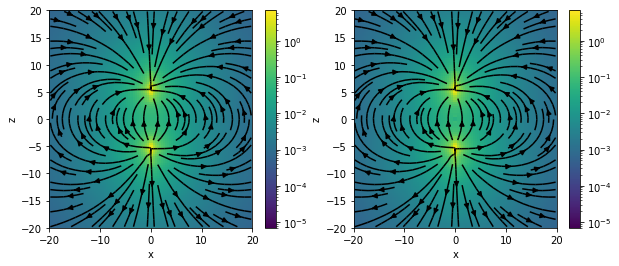

In [283]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_electric(background[:, "e"].real, ax=ax[0], colorbar=True)
plot_electric(dc_fields_hollow[:, "e"], ax=ax[1], colorbar=True)

In [284]:
np.mean(background[:, "e"].real) / np.mean(dc_fields_hollow[:, "e"])

1.0350362549270375

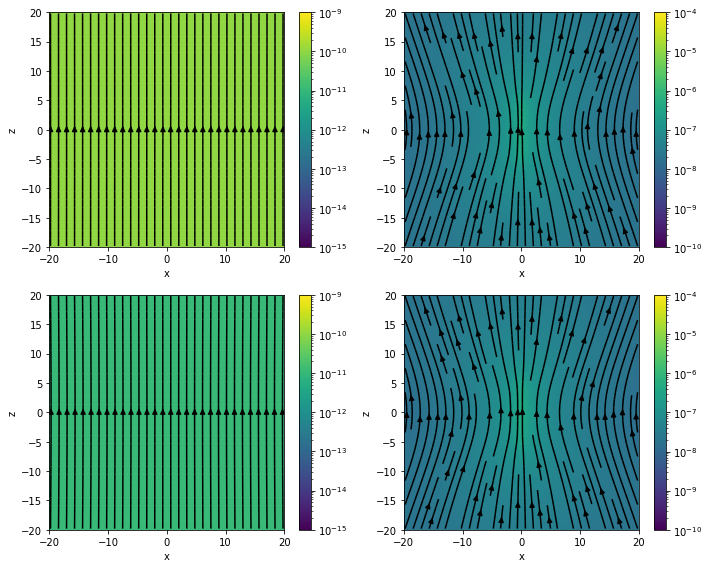

In [285]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

key = keys[1]

plot_electric(fields[key][:, "e"].real - dc_fields_hollow[:, "e"], ax=ax[0, 0], colorbar=True, vmax=1e-9)
plot_electric(fields[key][:, "e"].imag, ax=ax[0, 1], colorbar=True, vmax=1e-4)

plot_electric(inductive_fields[key][:, "e"].real, ax=ax[1, 0], colorbar=True, vmax=1e-9)
plot_electric(inductive_fields[key][:, "e"].imag, ax=ax[1, 1], colorbar=True, vmax=1e-4)

for a in ax.flatten():
    a.set_aspect(1)
plt.tight_layout()

In [286]:
np.mean(fields[key][:, "e"].real - dc_fields_hollow[:, "e"])

4.215866567102922e-11

In [287]:
np.mean(inductive_fields[key][:, "e"].real)

3.267374641746883e-12

In [288]:
np.mean(fields[key][:, "e"].real - dc_fields_hollow[:, "e"]) / np.mean(inductive_fields[key][:, "e"].real)

12.902917569467741

In [274]:
np.mean(fields[key][:, "e"].imag) / np.mean(inductive_fields[key][:, "e"].imag)

1.0039637918906972

In [ ]:
plot_magnetic(mmr_hollow[keys[0]]["b"], xlim=0.1*np.r_[-1, 1], colorbar=True, vmax=1e-10)

In [ ]:
fields_key_ind = -1
fields_key = keys[fields_key_ind]
fields_key

In [ ]:
e_magnetic = np.squeeze(fields[fields_key][:, "e"] - fields[keys[0]][:, "e"])
h_magnetic = np.squeeze(fields[fields_key][:, "h"] - fields[keys[0]][:, "h"])

e_inductive = np.squeeze(fields[fields_key][:, "e"] - dc_fields_hollow[:, "e"])
h_inductive = np.squeeze(fields[fields_key][:, "h"]) - mmr_hollow[fields_key]["h"]

In [ ]:
plot_magnetic(
    fields[fields_key][:, "h"].imag, 
    xlim=0.1*np.r_[-1, 1],
    colorbar=True,
    # vmax=1e-1
)

In [ ]:
plot_magnetic(
    h_inductive.real, 
    xlim=0.1*np.r_[-1, 1], 
    colorbar=True,
    # vmax=1e-7
)

In [ ]:
plot_electric(
    e_inductive.real, colorbar=True, #vmin=1e-13, vmax=1e-9
)

In [ ]:
plot_electric(e_inductive.imag, colorbar=True) #, vmin=1e-13, vmax=1e-9)

In [ ]:
plot_electric(e_magnetic.real, colorbar=True)

In [ ]:
plot_electric(e_magnetic.imag, colorbar=True)

In [ ]:
plot_magnetic(h_magnetic.real, xlim=0.25*np.r_[-1, 1], zlim=np.r_[-600, 10], colorbar=True)

In [ ]:
plot_magnetic(fields[keys[0]][:, "h"], xlim=0.25*np.r_[-1, 1], zlim=np.r_[-600, 10], colorbar=True, vmax=1e-1)

In [ ]:
div_e_inductive = mesh.face_divergence * e_inductive

In [ ]:
div_e_inductive.max()

In [ ]:
plot_magnetic(
    div_e_inductive.real, xlim=0.1*np.r_[-1, 1], zlim=np.r_[-600, 10],
    colorbar=True, 
)

In [ ]:
np.any(np.abs(h_magnetic) > 1e-10)

In [ ]:
div_e_magnetic = mesh.face_divergence * e_magnetic

In [ ]:
np.sum(div_e_magnetic.real != 0)

In [ ]:
np.max(np.abs(div_e_magnetic))

In [ ]:
np.where(np.abs(div_e_magnetic) > 1e-5)

In [ ]:
mesh.cell_centers[np.where(np.abs(div_e_magnetic) > 1e-5)[0]]

In [ ]:
plt.hist(np.abs(div_e_magnetic))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plot_magnetic(
    div_e_magnetic.real, 
    xlim=0.2*np.r_[-1, 1], 
    zlim=np.r_[-600, 10], 
    vmax=1e-14, #1e-6, 
    colorbar=True, ax=ax
)

In [ ]:
mesh.h[2].min()

In [ ]:
nonzeros = np.where(div_e_magnetic.imag > 1e-7)[0]
len(nonzeros)

In [ ]:
div_e_magnetic.shape

In [ ]:
mesh.cell_centers.shape

In [ ]:
mesh.cell_centers[nonzeros, :]

In [ ]:
mesh.n_faces

In [ ]:
fields[keys[0]][:, "b"].shape

# plot the integral of Phi b as a function of mu, e imag as a function of mu

In [ ]:
radial_inds_casing = (mesh.cell_centers_x <= casing_b) & (mesh.cell_centers_x >= casing_a)
mesh.cell_centers_x[radial_inds_casing]

In [ ]:
b_casing_integral = np.zeros_like(mur_casing, dtype=complex)

for i, val in enumerate(fields.values()):
    b_line = val[:, "b"][plot_inds_h] 
    b_line_area = (b_line[1:] + b_line[:-1]) / 2 * mesh.h[0].min() * mesh.cell_centers_x * 2 * np.pi
    b_line_in_casing = b_line_area[radial_inds_casing[:-1]]
    b_casing_integral[i] = np.sum(b_line_in_casing)

In [ ]:
z_loc = -300
x_loc = 0.1
plot_ind_ez = (
    (mesh.faces_z[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - z_loc))]) & 
    (mesh.faces_z[:, 0] == mesh.cell_centers_x[np.argmin(np.abs(mesh.cell_centers_x - x_loc))])
)
plot_ind_ez_all = np.hstack([ np.zeros(mesh.n_faces_x, dtype=bool), plot_ind_ez])

mesh.faces_z[plot_ind_ez, :]

In [ ]:
e_at_location = np.zeros_like(mur_casing, dtype=complex)

for i, val in enumerate(fields.values()): 
    e_at_location[i] = val[:, "e"][plot_ind_ez_all]

In [ ]:
mur_casing

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(mur_casing, b_casing_integral.real, "o")
ax[1].plot(mur_casing, e_at_location.imag, "o") 

ax[0].set_xlabel("mur")
ax[0].set_title("integral of B real")

ax[1].set_xlabel("mur")
ax[1].set_title(f"Ez at x={x_loc} m")

for a in ax.flatten():
    a.grid()

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(np.atleast_2d(b_casing_integral.real).T, -e_at_location.imag)

In [ ]:
reg.coef_, reg.intercept_

In [ ]:
fig, ax = plt.subplots(1, 1)

for i in range(len(mur_casing)): 
    ax.plot(b_casing_integral[i].real, e_at_location[i].imag, "o")
ax.grid()

ax.set_xlabel("Integrated B")
ax.set_ylabel(f"Ez imag at r={x_loc}m")

In [ ]:
e_at_location.imag

In [ ]:
# fig, ax = plt.subplots(1, 1)

# for i in range(len(mur_casing)): 
#     ax.plot(b_casing_integral[i].real/b_casing_integral[0].real, e_at_location[i].imag/e_at_location[0].imag, "o")
# ax.grid()

# # ax.set_xlabel("Integrated B")
# # ax.set_ylabel(f"Er imag at r={x_loc}m")

In [ ]:
z_loc = -300
x_loc = 0.1
plot_ind_ex = (
    (mesh.faces_x[:, 2] == mesh.cell_centers_z[np.argmin(np.abs(mesh.cell_centers_z - z_loc))]) & 
    (mesh.faces_x[:, 0] == mesh.nodes_x[np.argmin(np.abs(mesh.nodes_x - x_loc))])
)
plot_ind_ex_all = np.hstack([plot_ind_ex, np.zeros(mesh.n_faces_z, dtype=bool)])

mesh.faces_x[plot_ind_ex, :]

In [ ]:
ex_at_location = np.zeros_like(mur_casing, dtype=complex)

for i, val in enumerate(fields.values()): 
    ex_at_location[i] = val[:, "e"][plot_ind_ex_all]

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(mur_casing, b_casing_integral.real, "o")
ax[1].plot(mur_casing, -ex_at_location.imag, "o") 

ax[0].set_xlabel("mur")
ax[0].set_title("integral of B real")

ax[1].set_xlabel("mur")
ax[1].set_title(f"Ex at x={x_loc} m")

for a in ax.flatten():
    a.grid()

In [ ]:
fig, ax = plt.subplots(1, 1)

for i in range(len(mur_casing)): 
    ax.plot(b_casing_integral[i].real, -ex_at_location[i].imag, "o")
ax.grid()

ax.set_xlabel("Integrated B")
ax.set_ylabel(f"Er imag at r={x_loc}m")

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)

xlim=np.r_[0, 0.3]
zlim=np.r_[-600, 10]

vminreal = 1e-7
vmaxreal = 1e-1

vminimag = 1e-10
vmaximag = 1e-7

for i, key in enumerate(keys[::2]): 

    legend = f"{key.split('_')[-1][3:]} $\mu_0$"
    
    ax[0, i].set_title(f"E real {legend}")
    ax[1, i].set_title(f"E imag {legend}")
    
    plot_fields(
        fields[key][:, "e"], component="real", ax=ax[0, i], xlim=xlim, zlim=zlim, aspect=False, vmin=vminreal, vmax=vmaxreal, 
    )
    plot_fields(
        fields[key][:, "e"], component="imag", ax=ax[1, i], xlim=xlim, zlim=zlim, aspect=False, vmin=vminimag, vmax=vmaximag, 
    )

plt.tight_layout()